In [1]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt 

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

Text(0.5, 1.0, 'Job Schedule Full-time vs. Part-time')

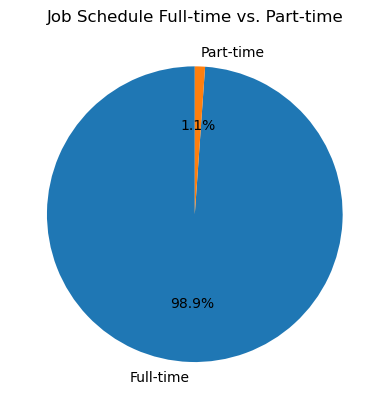

In [9]:
df = df.query("job_schedule_type == 'Full-time' or job_schedule_type == 'Part-time'")

df_ft_pt = (
    df.groupby(['job_title_short', 'job_schedule_type'])
    .size()
    .unstack()
)

df_ft_pt.sum().plot(kind='pie', startangle = 90, labels= ['Full-time', 'Part-time'], autopct='%1.1f%%')
plt.title('Job Schedule Full-time vs. Part-time')
